In [1]:
!pip install m2cgen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 3.0 MB/s eta 0:00:00


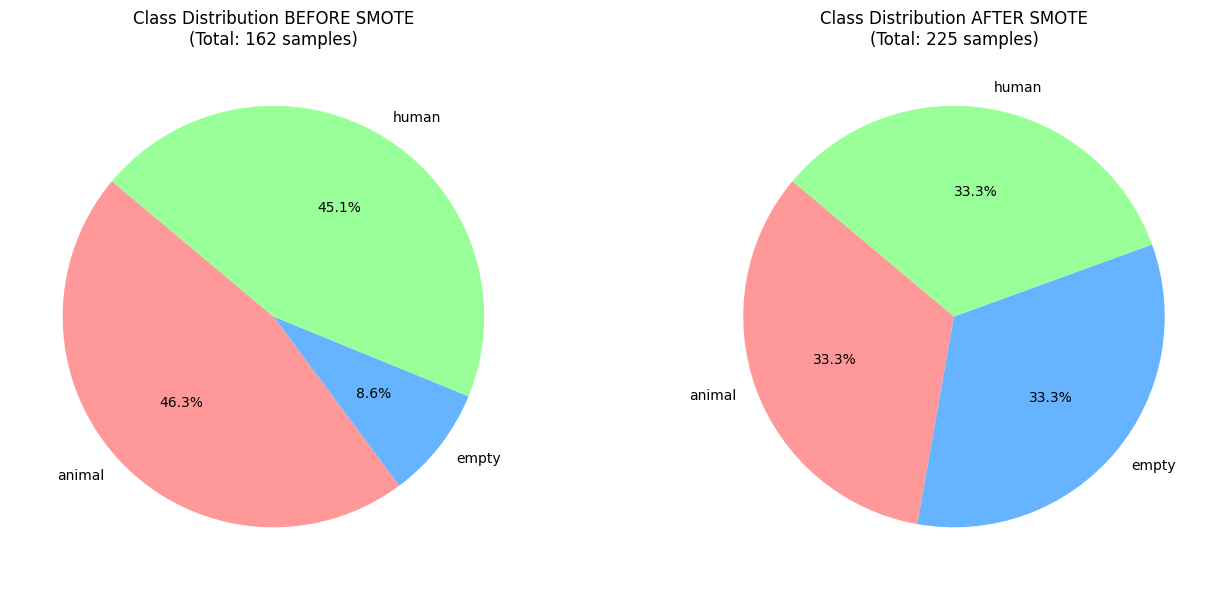

Preprocessing complete. Training set expanded from 162 to 225 samples.


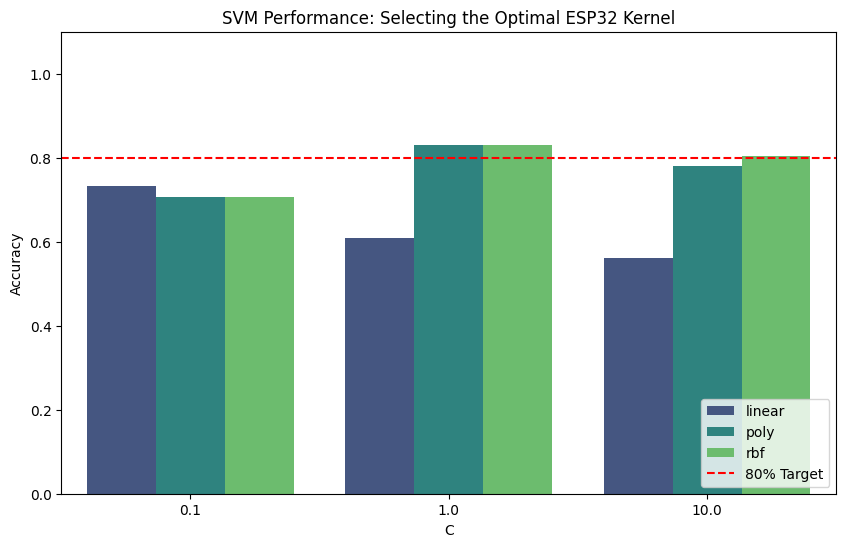

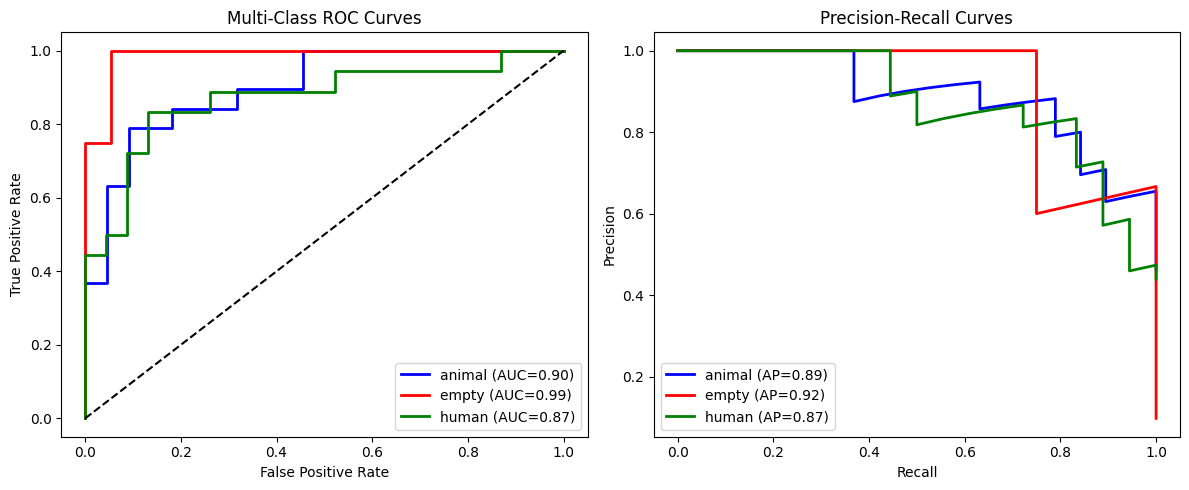


--- Starting Polynomial Degree Analysis ---


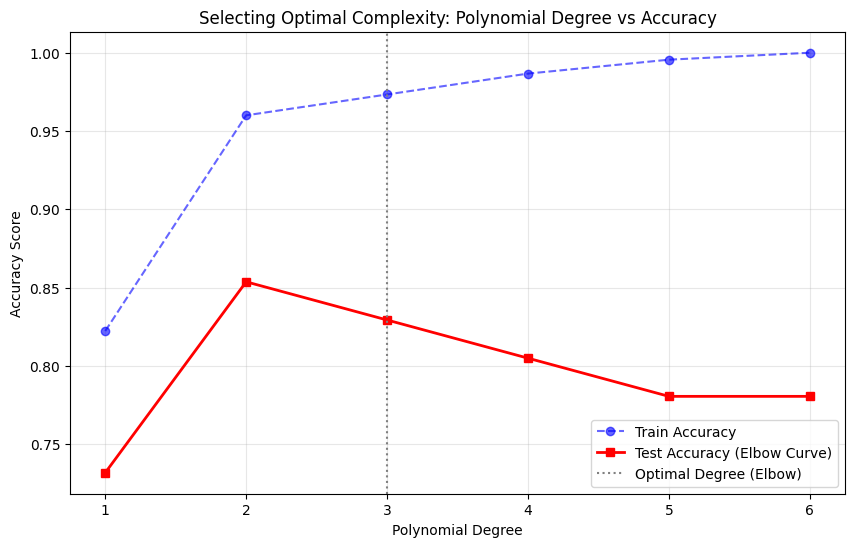

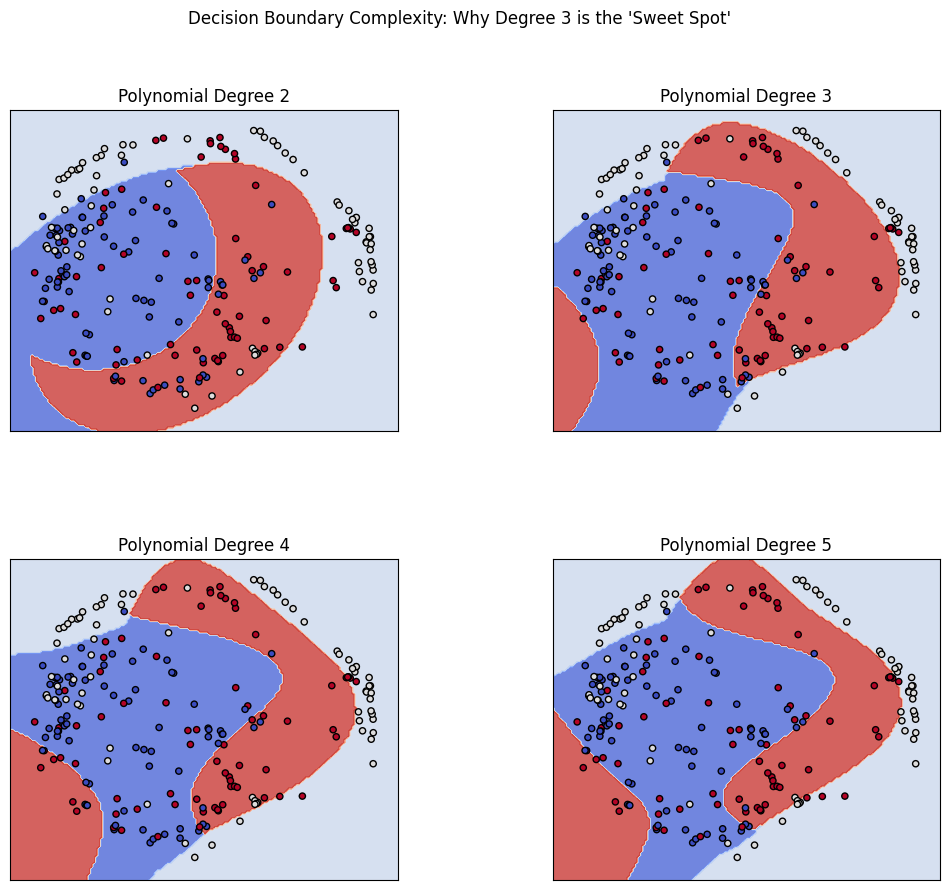

✅ Analysis Complete: 'elbow_curve.png' and 'polynomial_boundaries.png' generated.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, roc_curve,
                             auc, precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
from itertools import cycle

# 1. LOAD AND PREPROCESS
df = pd.read_csv('thermal_master_dataset.csv')
X = df.drop('label', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['label'])
class_names = le.classes_

X_norm = X.apply(lambda row: (row - row.mean()) / (row.std() + 1e-8), axis=1)

# 2. Stratified Split
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)

# --- PIE CHART DATA PREPARATION ---
# Get labels for the "Before" state
before_counts = pd.Series(y_train_raw).value_counts().sort_index()
labels = le.inverse_transform(before_counts.index)

# 3. SMOTE Preprocessing
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train_raw)

# Get labels for the "After" state
after_counts = pd.Series(y_train_smote).value_counts().sort_index()

# --- GENERATE PIE CHARTS ---
plt.figure(figsize=(14, 6))

# Subplot 1: Before SMOTE
plt.subplot(1, 2, 1)
plt.pie(before_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title(f"Class Distribution BEFORE SMOTE\n(Total: {len(y_train_raw)} samples)")

# Subplot 2: After SMOTE
plt.subplot(1, 2, 2)
plt.pie(after_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title(f"Class Distribution AFTER SMOTE\n(Total: {len(y_train_smote)} samples)")

plt.tight_layout()
plt.savefig('smote_distribution_comparison.png', dpi=300)
plt.show()

# 4. Noise Injection & Training
noise_factor = 0.05
noise = np.random.normal(0, noise_factor, X_train_smote.shape)
X_train_final = X_train_smote + noise

print(f"Preprocessing complete. Training set expanded from {len(X_train_raw)} to {len(X_train_final)} samples.")
# 5. KERNEL & C-VALUE BENCHMARKING
comparison_results = []
# Testing Linear, Poly (d=3), and RBF kernels across C values
for k in ['linear', 'poly', 'rbf']:
    for c in [0.1, 1, 10]:
        clf = svm.SVC(kernel=k, C=c, degree=3)
        clf.fit(X_train_final, y_train_smote)
        acc = accuracy_score(y_test, clf.predict(X_test))
        comparison_results.append({'Kernel': k, 'C': c, 'Accuracy': acc})

# Visualize the benchmark
res_df = pd.DataFrame(comparison_results)
plt.figure(figsize=(10, 6))
sns.barplot(x='C', y='Accuracy', hue='Kernel', data=res_df, palette='viridis')
plt.title("SVM Performance: Selecting the Optimal ESP32 Kernel")
plt.ylim(0, 1.1)
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Target')
plt.legend(loc='lower right')
plt.savefig('kernel_comparison.png', dpi=300)
plt.show()

# 6. FINAL MODEL EVALUATION (ROC & PRECISION-RECALL)
# We finalize with the Poly degree-3 kernel for best 8x8 separation
best_model = svm.SVC(kernel='poly', degree=3, C=1.0, coef0=1, probability=True, class_weight='balanced')
best_model.fit(X_train_final, y_train_smote)

y_score = best_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = cycle(['blue', 'red', 'green'])

# Plotting ROC Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves')
plt.legend(loc="lower right")

# Plotting Precision-Recall Curves
plt.subplot(1, 2, 2)
for i, color in zip(range(3), colors):
    p, r, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(r, p, color=color, lw=2, label=f'{class_names[i]} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="lower left")

plt.tight_layout()
plt.savefig('performance_metrics.png', dpi=300)
plt.show()
#  POLYNOMIAL ANALYSIS

print("\n--- Starting Polynomial Degree Analysis ---")

# 7. ELBOW CURVE GENERATION
degrees = [1, 2, 3, 4, 5, 6]
test_accs = []
train_accs = []

for d in degrees:
    temp_clf = svm.SVC(kernel='poly', degree=d, C=1.0, coef0=1)
    temp_clf.fit(X_train_final, y_train_smote)
    train_accs.append(accuracy_score(y_train_smote, temp_clf.predict(X_train_final)))
    test_accs.append(accuracy_score(y_test, temp_clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_accs, 'o--', label='Train Accuracy', color='blue', alpha=0.6)
plt.plot(degrees, test_accs, 's-', label='Test Accuracy (Elbow Curve)', color='red', linewidth=2)
plt.axvline(x=3, color='gray', linestyle=':', label='Optimal Degree (Elbow)')
plt.title("Selecting Optimal Complexity: Polynomial Degree vs Accuracy")
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('elbow_curve.png', dpi=300)
plt.show()

# 8. VISUALIZING DECISION BOUNDARIES (PCA-REDUCED)
# Since thermal data is 64D, we reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_final)

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

# Create meshgrid for visualization
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

fig, sub = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)
deg_list = [2, 3, 4, 5]

for d, ax in zip(deg_list, sub.flatten()):
    pca_clf = svm.SVC(kernel='poly', degree=d, C=1.0, coef0=1)
    pca_clf.fit(X_train_pca, y_train_smote)

    plot_contours(ax, pca_clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_smote, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_title(f"Polynomial Degree {d}")
    ax.set_xticks(())
    ax.set_yticks(())

plt.suptitle("Decision Boundary Complexity: Why Degree 3 is the 'Sweet Spot'")
plt.savefig('polynomial_boundaries.png', dpi=300)
plt.show()

print("✅ Analysis Complete: 'elbow_curve.png' and 'polynomial_boundaries.png' generated.")

In [12]:
with open("perimeter_model.h", "w") as f:
  f.write(m2c.export_to_c(poly_clf))